## Order & Product Profitability Risk Modeling

### Notebook 2 — Exploratory Data Analysis (EDA)

#### Objective
Understand patterns in order profitability and identify factors that may contribute to low or negative profit.

#### Key Focus Areas
- Profit distribution
- Impact of discounts on profit
- Relationship between order size and profit
- Effect of shipping mode on profitability
- Regional patterns in profit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/orders_clean.csv")
df.head()

,Order Id,total_sales,total_order_value,total_discount,total_quantity,order_profit,Customer Segment,Market,Shipping Mode,Order Region,Order Country
0,1,299.980011,239.979996,60.000000,1,88.790001,Consumer,LATAM,Standard Class,Central America,México
1,2,579.980011,529.380005,50.600000,7,195.900002,Consumer,LATAM,Standard Class,South America,Colombia
2,4,699.850010,620.870014,78.980000,14,124.090000,Home Office,LATAM,Standard Class,South America,Colombia
3,5,1129.860039,987.070007,142.789999,10,390.089995,Consumer,LATAM,Standard Class,South America,Colombia
4,7,579.920013,525.520004,54.400000,7,203.929998,Consumer,LATAM,Second Class,South America,Brasil


### Profit Distribution

In [3]:
df['order_profit'].describe()

count    65752.000000
mean        60.331290
std        189.716897
min      -4325.849979
25%          7.797500
50%         72.734999
75%        158.669999
max        980.280006
Name: order_profit, dtype: float64

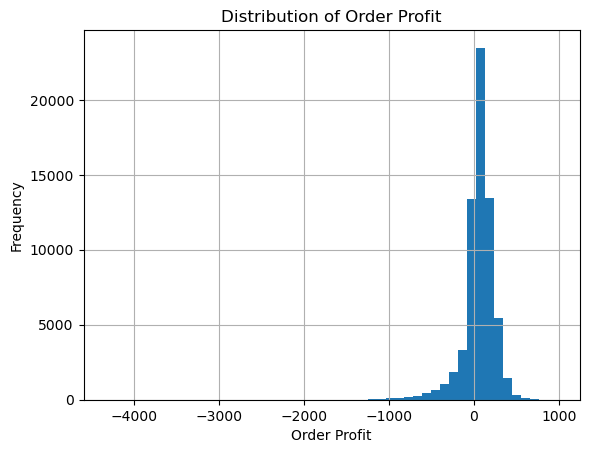

In [4]:
plt.figure()
df['order_profit'].hist(bins=50)
plt.title("Distribution of Order Profit")
plt.xlabel("Order Profit")
plt.ylabel("Frequency")
plt.show()

In [32]:
loss_percentage = (df['order_profit'] < 0).mean()

print("Loss-making orders (%):", loss_percentage * 100)

Loss-making orders (%): 21.15372916413189


**Observation:**
Around 21% of orders are loss-making. While most orders are profitable, a significant portion generates losses. The distribution is skewed with extreme negative values, indicating that a small number of orders contribute disproportionately to overall losses.

### Discount vs Profit

In [7]:
df['discount_pct'] = df['total_discount'] / df['total_sales']

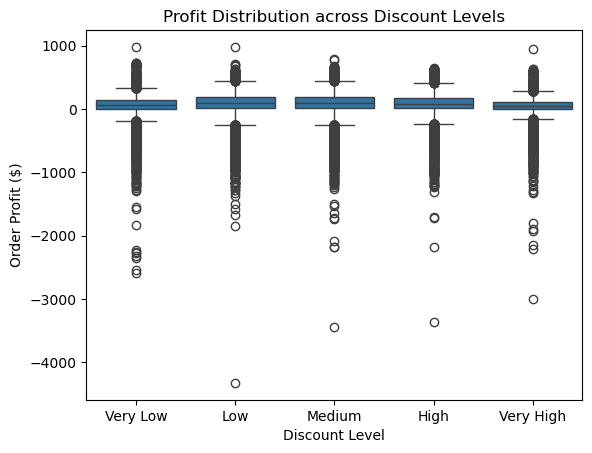

In [12]:
plt.figure()

sns.boxplot(x=df['discount_bins'], y=df['order_profit'])

plt.title("Profit Distribution across Discount Levels")
plt.xlabel("Discount Level")
plt.ylabel("Order Profit ($)")

plt.show()

C:\Users\Abdul Basit\AppData\Local\Temp\ipykernel_16588\3047065221.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loss_rate = df.groupby('discount_bins')['is_loss'].mean()


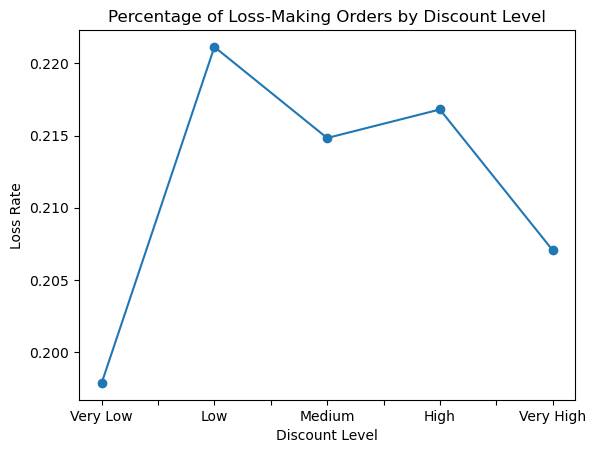

In [13]:
df['is_loss'] = df['order_profit'] < 0

loss_rate = df.groupby('discount_bins')['is_loss'].mean()

plt.figure()
loss_rate.plot(marker='o')

plt.title("Percentage of Loss-Making Orders by Discount Level")
plt.xlabel("Discount Level")
plt.ylabel("Loss Rate")

plt.show()

C:\Users\Abdul Basit\AppData\Local\Temp\ipykernel_16588\4148024485.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_profit = df.groupby('discount_bins')['order_profit'].mean()


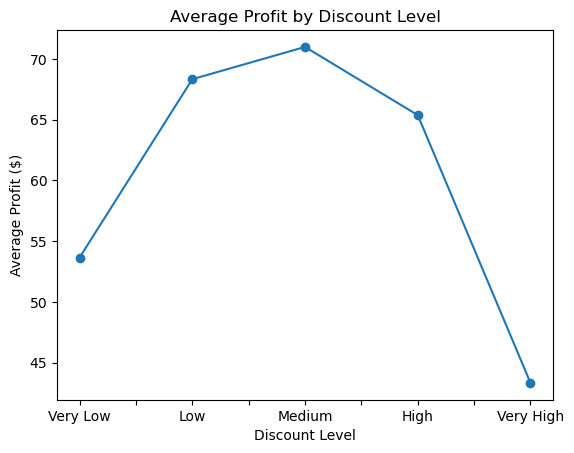

In [11]:
df['discount_bins'] = pd.qcut(df['discount_pct'], q=5, labels=[
    "Very Low", "Low", "Medium", "High", "Very High"
])

avg_profit = df.groupby('discount_bins')['order_profit'].mean()

plt.figure()
avg_profit.plot(marker='o')

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount Level")
plt.ylabel("Average Profit ($)")

plt.show()

**Observation:**
Discount does not show a strong direct relationship with profit. Losses occur across all discount levels, suggesting other factors also influence profitability.

### Order Size vs Profit

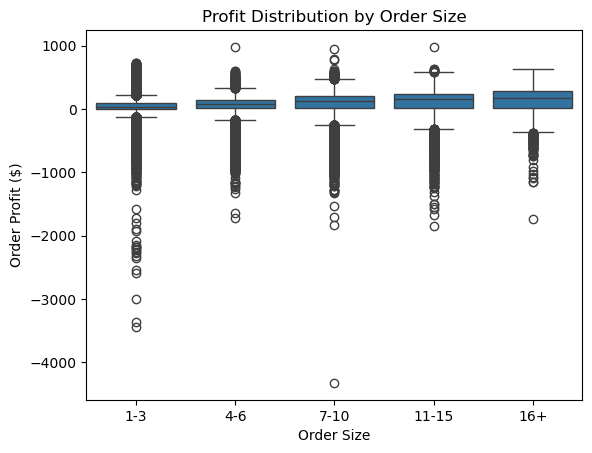

In [19]:
df['quantity_group'] = pd.cut(
    df['total_quantity'],
    bins=[0, 3, 6, 10, 15, 25],
    labels=["1-3", "4-6", "7-10", "11-15", "16+"]
)

plt.figure()

sns.boxplot(x=df['quantity_group'], y=df['order_profit'])

plt.title("Profit Distribution by Order Size")
plt.xlabel("Order Size")
plt.ylabel("Order Profit ($)")

plt.show()

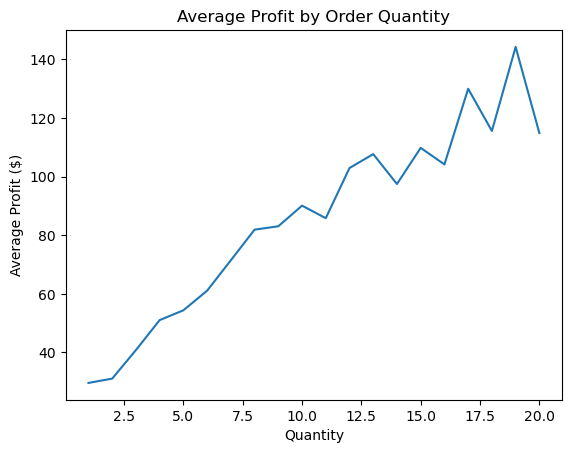

In [15]:
df.groupby('total_quantity')['order_profit'].mean().head(20).plot()

plt.title("Average Profit by Order Quantity")
plt.xlabel("Quantity")
plt.ylabel("Average Profit ($)")

plt.show()

C:\Users\Abdul Basit\AppData\Local\Temp\ipykernel_16588\3557944334.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loss_rate = df.groupby('quantity_group')['is_loss'].mean()


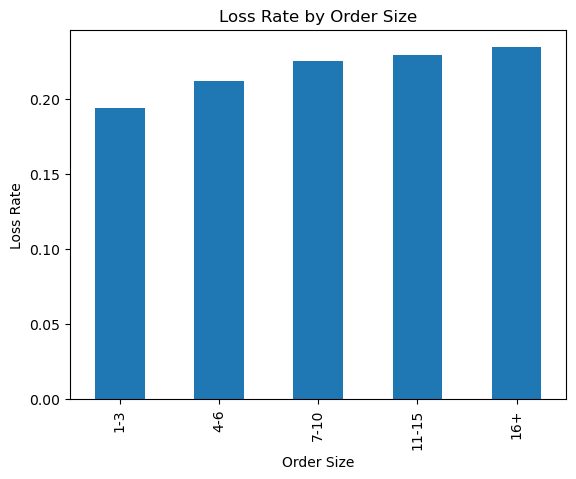

In [20]:
loss_rate = df.groupby('quantity_group')['is_loss'].mean()

plt.figure()

loss_rate.plot(kind='bar')

plt.title("Loss Rate by Order Size")
plt.xlabel("Order Size")
plt.ylabel("Loss Rate")

plt.show()

**Observation:**
Larger orders tend to generate higher profit, but they also show a higher loss rate, indicating increased variability.

### Shipping Mode vs Profit

In [21]:
df['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    39324
Second Class      12778
First Class       10079
Same Day           3571
Name: count, dtype: int64

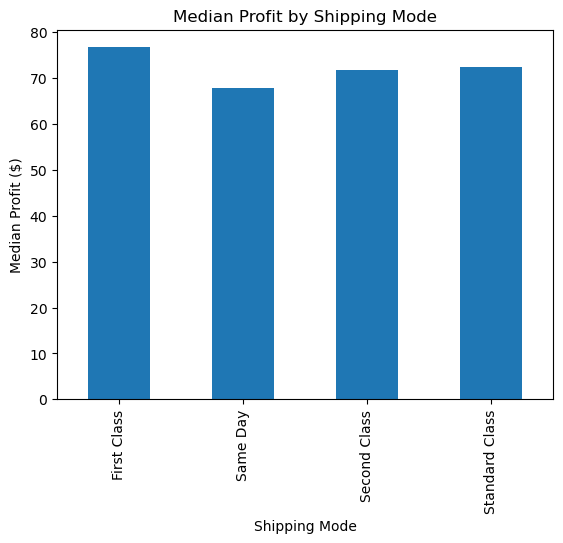

In [27]:
median_profit = df.groupby('Shipping Mode')['order_profit'].median()

plt.figure()
median_profit.plot(kind='bar')

plt.title("Median Profit by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Median Profit ($)")

plt.show()

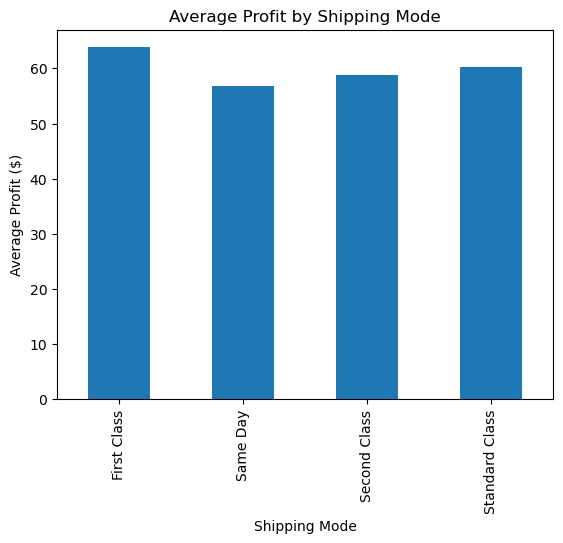

In [23]:
avg_profit = df.groupby('Shipping Mode')['order_profit'].mean()

plt.figure()

avg_profit.plot(kind='bar')

plt.title("Average Profit by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Profit ($)")

plt.show()

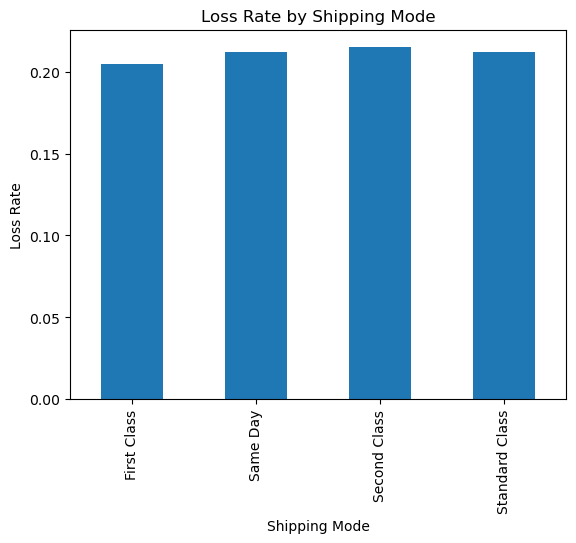

In [24]:
loss_rate = df.groupby('Shipping Mode')['is_loss'].mean()

plt.figure()

loss_rate.plot(kind='bar')

plt.title("Loss Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Loss Rate")

plt.show()

**Observation:**
Shipping mode has only a small effect on profit, with minor differences across categories.

### Market / Region Analysis

In [28]:
df['Market'].value_counts()

Market
Europe          18561
Pacific Asia    17577
LATAM           17181
USCA             8579
Africa           3854
Name: count, dtype: int64

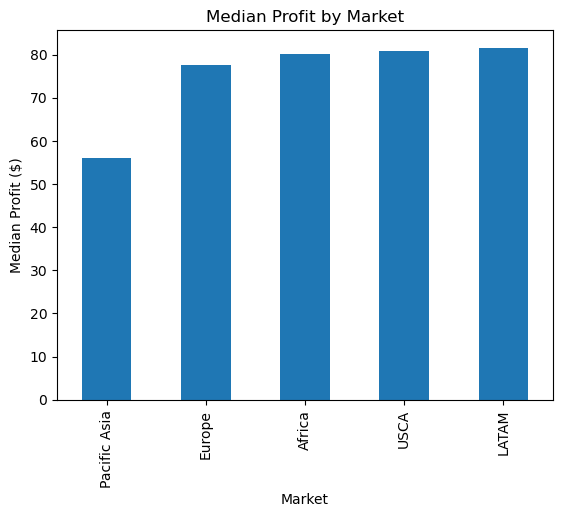

In [29]:
median_profit_market = df.groupby('Market')['order_profit'].median()

plt.figure()
median_profit_market.sort_values().plot(kind='bar')

plt.title("Median Profit by Market")
plt.xlabel("Market")
plt.ylabel("Median Profit ($)")

plt.show()

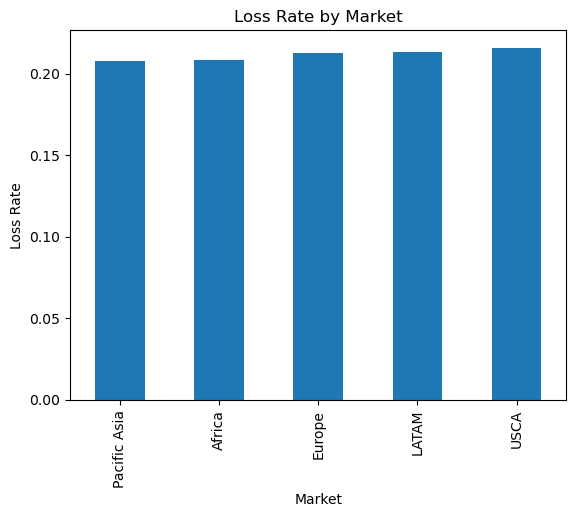

In [30]:
loss_rate_market = df.groupby('Market')['is_loss'].mean()

plt.figure()
loss_rate_market.sort_values().plot(kind='bar')

plt.title("Loss Rate by Market")
plt.xlabel("Market")
plt.ylabel("Loss Rate")

plt.show()

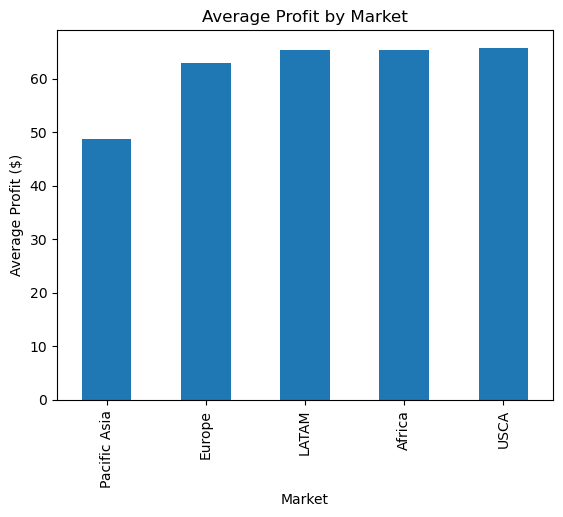

In [31]:
avg_profit_market = df.groupby('Market')['order_profit'].mean()

plt.figure()
avg_profit_market.sort_values().plot(kind='bar')

plt.title("Average Profit by Market")
plt.xlabel("Market")
plt.ylabel("Average Profit ($)")

plt.show()

**Observation:**
Some markets show slightly higher profit levels, but loss rates are similar across regions.

## Notebook Summary & Key Learnings

### What I did in this notebook

In this notebook, I explored the cleaned order-level dataset to understand what factors affect profitability.

I focused on key variables like:
- Profit distribution
- Discount
- Order size
- Shipping mode
- Market

---

### Key Observations

- Most orders are profitable, but some have very large losses
- Profit distribution is skewed with extreme negative values
- Order size shows a clear relationship with profit — larger orders tend to generate higher profit
- However, larger orders also have a slightly higher loss rate, indicating higher risk
- Discount does not show a strong direct relationship with profit
- Shipping mode has only a small impact on profitability
- Market shows some differences in profit levels, but loss rates are similar across regions

---

### Business Understanding

- A small number of orders are responsible for large losses
- Increasing order size can improve profit but also increases risk
- Discount and shipping decisions alone do not fully explain profitability
- Profitability depends on multiple factors combined

---

### What I learned

- Not all variables have strong predictive power
- It is important to test assumptions instead of relying on intuition
- Proper visualization is important for understanding patterns

---

### What I will do next

- Create new features based on insights (e.g., profit risk)
- Prepare dataset for modeling
- Build models to predict low-profit or loss-making orders